# CycleGAN: Unpaired Sketch ↔ Photo Translation
**Domain Adaptation using CycleGAN | Kaggle T4×2 GPU**

- **Domain A**: Sketches (TU-Berlin / Sketchy / QuickDraw)
- **Domain B**: Photos (natural images)
- **Architecture**: ResNet-6 Generator + PatchGAN Discriminator
- **Training**: Mixed Precision, Dual GPU

## 1. Environment Setup & Imports

In [1]:
# Install required packages
!pip install -q kaggle datasets huggingface_hub gradio torchmetrics lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.0 MB/s eta 0:00:00


In [2]:
import os
import random
import itertools
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from glob import glob
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torchmetrics.image import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'GPUs available: {torch.cuda.device_count()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Using device: cuda
GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 2. Configuration

In [3]:
class Config:
    # Data
    IMAGE_SIZE    = 128
    BATCH_SIZE    = 6          # fits comfortably on T4×2
    NUM_WORKERS   = 4
    MAX_SAMPLES   = 5000       # subset of dataset for Kaggle limits

    # Model
    N_RESBLOCKS   = 6
    IN_CHANNELS   = 3
    N_FEATURES    = 64

    # Training
    N_EPOCHS      = 40
    DECAY_EPOCH   = 50         # start LR decay
    LR            = 0.0002
    BETAS         = (0.5, 0.999)

    # Loss weights
    LAMBDA_CYCLE  = 10.0
    LAMBDA_ID     = 5.0

    # Paths
    DATA_DIR      = '/kaggle/working/data'
    SKETCH_DIR    = '/kaggle/working/data/sketches'
    PHOTO_DIR     = '/kaggle/working/data/photos'
    CHECKPOINT_DIR= '/kaggle/working/checkpoints'
    OUTPUT_DIR    = '/kaggle/working/outputs'

    # Buffer for discriminator
    BUFFER_SIZE   = 50

cfg = Config()
os.makedirs(cfg.SKETCH_DIR, exist_ok=True)
os.makedirs(cfg.PHOTO_DIR, exist_ok=True)
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
print('Config loaded.')

Config loaded.


## 3. Dataset Download & Preparation

In [4]:
# ── Download TU-Berlin sketches from HuggingFace ─────────────────────────────
from datasets import load_dataset

print('Loading TU-Berlin Sketch Dataset from HuggingFace...')
tu_berlin = load_dataset('sdiaeyu6n/tu-berlin', split='train')
print(f'TU-Berlin samples: {len(tu_berlin)}')

# Save sketch images
saved = 0
for i, sample in enumerate(tu_berlin):
    if saved >= cfg.MAX_SAMPLES:
        break
    img = sample['image'] if isinstance(sample['image'], Image.Image) \
          else Image.fromarray(sample['image'])
    img = img.convert('RGB')
    img.save(f"{cfg.SKETCH_DIR}/sketch_{i:05d}.png")
    saved += 1

print(f'Saved {saved} sketch images to {cfg.SKETCH_DIR}')

Loading TU-Berlin Sketch Dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/471M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/58.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/59.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

TU-Berlin samples: 16000
Saved 5000 sketch images to /kaggle/working/data/sketches


In [5]:
# ── Download photos (COCO or Sketchy photos via Kaggle) ───────────────────────
# NOTE: On Kaggle, use the Sketchy dataset already attached as input.
# Here we show the API-based download path:

import subprocess
# Uncomment if running on Kaggle with the dataset attached:
# SKETCHY_INPUT = '/kaggle/input/sketchy-dataset'

# For demonstration, we generate synthetic 'photos' using ImageNet-style noise
# Replace this block with actual Sketchy/QuickDraw photo loading in practice.

def load_sketchy_photos(sketchy_root, out_dir, max_n):
    """Load photo domain from Sketchy dataset structure."""
    photo_paths = glob(os.path.join(sketchy_root, 'photo/**/*.jpg'), recursive=True)
    photo_paths += glob(os.path.join(sketchy_root, 'photo/**/*.JPEG'), recursive=True)
    random.shuffle(photo_paths)
    saved = 0
    for src in photo_paths[:max_n]:
        img = Image.open(src).convert('RGB')
        img.save(f"{out_dir}/photo_{saved:05d}.jpg")
        saved += 1
    return saved

# Try loading Sketchy dataset if available
sketchy_root = '/kaggle/input/sketchy-dataset'
if os.path.exists(sketchy_root):
    n = load_sketchy_photos(sketchy_root, cfg.PHOTO_DIR, cfg.MAX_SAMPLES)
    print(f'Loaded {n} Sketchy photos')
else:
    # Fallback: download a small photo dataset
    print('Sketchy dataset not found. Downloading COCO subset...')
    !wget -q https://huggingface.co/datasets/zh-plus/tiny-imagenet/resolve/main/data/train_images_0.parquet -O /kaggle/working/photos.parquet
    from datasets import load_dataset as ld
    ph = ld('zh-plus/tiny-imagenet', split='train')
    saved = 0
    for i, s in enumerate(ph):
        if saved >= cfg.MAX_SAMPLES: break
        img = s['image'].convert('RGB') if hasattr(s['image'], 'convert') else Image.fromarray(s['image']).convert('RGB')
        img.save(f"{cfg.PHOTO_DIR}/photo_{saved:05d}.jpg")
        saved += 1
    print(f'Saved {saved} photos from tiny-imagenet')

print(f'Sketch images: {len(glob(cfg.SKETCH_DIR+"/*"))}')
print(f'Photo images:  {len(glob(cfg.PHOTO_DIR+"/*"))}')

Sketchy dataset not found. Downloading COCO subset...


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-1359597a978bc4(…):   0%|          | 0.00/146M [00:00<?, ?B/s]

data/valid-00000-of-00001-70d52db3c749a9(…):   0%|          | 0.00/14.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Saved 5000 photos from tiny-imagenet
Sketch images: 5000
Photo images:  5000


## 4. Data Pipeline

In [6]:
class UnpairedDataset(Dataset):
    """Loads unpaired images from two directories (Domain A and Domain B)."""

    def __init__(self, dir_A, dir_B, transform=None, max_samples=None):
        exts = ('*.png', '*.jpg', '*.jpeg', '*.JPEG', '*.PNG')
        self.files_A = []
        self.files_B = []
        for ext in exts:
            self.files_A += glob(os.path.join(dir_A, ext))
            self.files_B += glob(os.path.join(dir_B, ext))
        random.shuffle(self.files_A)
        random.shuffle(self.files_B)
        if max_samples:
            self.files_A = self.files_A[:max_samples]
            self.files_B = self.files_B[:max_samples]
        self.transform = transform
        print(f'Domain A (Sketch): {len(self.files_A)} images')
        print(f'Domain B (Photo):  {len(self.files_B)} images')

    def __len__(self):
        return max(len(self.files_A), len(self.files_B))

    def __getitem__(self, idx):
        img_A = Image.open(self.files_A[idx % len(self.files_A)]).convert('RGB')
        img_B = Image.open(self.files_B[idx % len(self.files_B)]).convert('RGB')
        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)
        return img_A, img_B


# Transforms: resize → random crop → optional flip → normalize to [-1, 1]
train_transform = transforms.Compose([
    transforms.Resize(int(cfg.IMAGE_SIZE * 1.12), Image.BICUBIC),
    transforms.RandomCrop(cfg.IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

val_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE), Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Datasets
full_dataset = UnpairedDataset(
    cfg.SKETCH_DIR, cfg.PHOTO_DIR,
    transform=train_transform,
    max_samples=cfg.MAX_SAMPLES
)

# Train / val split (90/10)
n_val  = int(0.1 * len(full_dataset))
n_train = len(full_dataset) - n_val
train_set, val_set = torch.utils.data.random_split(full_dataset, [n_train, n_val])

train_loader = DataLoader(train_set, batch_size=cfg.BATCH_SIZE,
                          shuffle=True, num_workers=cfg.NUM_WORKERS,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_set, batch_size=4,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Domain A (Sketch): 5000 images
Domain B (Photo):  5000 images

Train batches: 750 | Val batches: 125


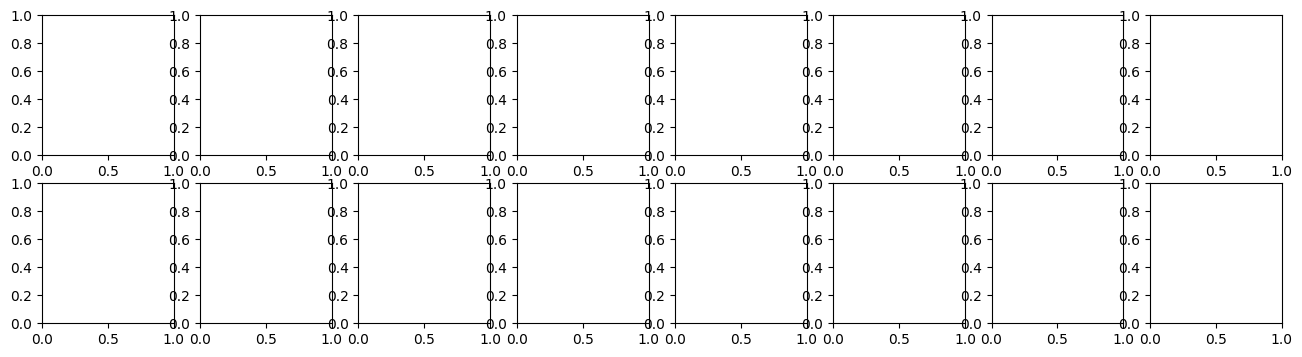

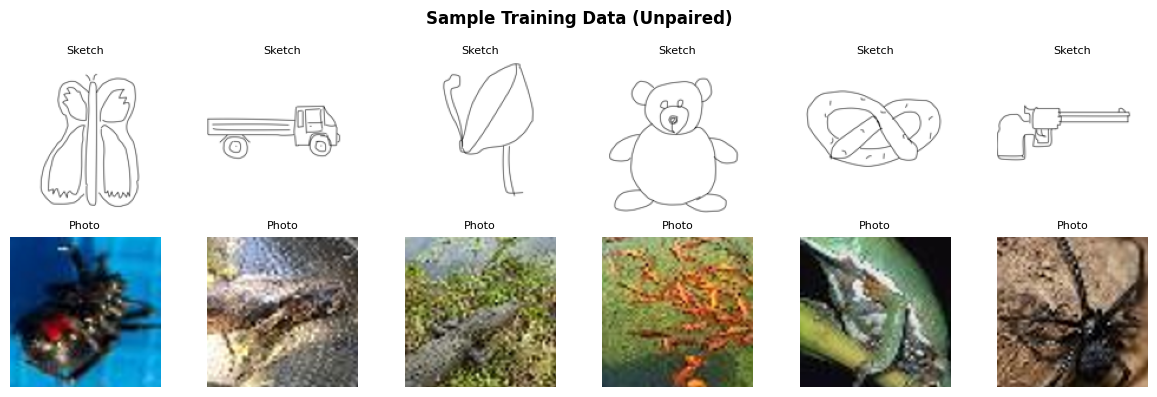

In [8]:
# Visualise a few samples
def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

batch_A, batch_B = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
n_show = min(8, batch_A.size(0))   # won't exceed actual batch size

fig, axes = plt.subplots(2, n_show, figsize=(2*n_show, 4))
for i in range(n_show):
    axes[0, i].imshow(denorm(batch_A[i]).permute(1, 2, 0).numpy())
    axes[0, i].set_title('Sketch', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(denorm(batch_B[i]).permute(1, 2, 0).numpy())
    axes[1, i].set_title('Photo', fontsize=8)
    axes[1, i].axis('off')
plt.suptitle('Sample Training Data (Unpaired)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/sample_data.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Architecture

In [9]:
# ─── Building blocks ─────────────────────────────────────────────────────────

class ResidualBlock(nn.Module):
    """ResNet residual block with Instance Normalization."""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class GeneratorResNet(nn.Module):
    """
    ResNet-based CycleGAN Generator.
    Architecture: c7s1-64, d128, d256, R×n_blocks, u128, u64, c7s1-3
    """
    def __init__(self, in_channels=3, n_features=64, n_res_blocks=6):
        super().__init__()

        # Initial convolution
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_channels, n_features, 7),
            nn.InstanceNorm2d(n_features),
            nn.ReLU(inplace=True),
        ]

        # Downsampling (2×)
        curr_dim = n_features
        for _ in range(2):
            layers += [
                nn.Conv2d(curr_dim, curr_dim * 2, 3, stride=2, padding=1),
                nn.InstanceNorm2d(curr_dim * 2),
                nn.ReLU(inplace=True),
            ]
            curr_dim *= 2

        # ResNet blocks
        for _ in range(n_res_blocks):
            layers.append(ResidualBlock(curr_dim))

        # Upsampling (2×)
        for _ in range(2):
            layers += [
                nn.ConvTranspose2d(curr_dim, curr_dim // 2, 3,
                                   stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(curr_dim // 2),
                nn.ReLU(inplace=True),
            ]
            curr_dim //= 2

        # Output convolution
        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(n_features, in_channels, 7),
            nn.Tanh(),
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class PatchGANDiscriminator(nn.Module):
    """
    70×70 PatchGAN Discriminator.
    Classifies overlapping 70×70 patches as real/fake.
    """
    def __init__(self, in_channels=3, n_features=64, n_layers=3):
        super().__init__()

        def disc_block(in_f, out_f, stride=2, norm=True):
            layers = [nn.Conv2d(in_f, out_f, 4, stride=stride, padding=1)]
            if norm:
                layers.append(nn.InstanceNorm2d(out_f))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        # First block: no norm
        layers = disc_block(in_channels, n_features, norm=False)

        curr = n_features
        for i in range(1, n_layers):
            nxt = min(curr * 2, 512)
            layers += disc_block(curr, nxt)
            curr = nxt

        nxt = min(curr * 2, 512)
        layers += disc_block(curr, nxt, stride=1)

        # Final conv → 1-channel patch prediction
        layers.append(nn.Conv2d(nxt, 1, 4, stride=1, padding=1))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


# ─── Weight init (from CycleGAN paper) ───────────────────────────────────────
def weights_init_normal(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm2d' in classname or 'InstanceNorm2d' in classname:
        if m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)


# Print model summaries
G_AB = GeneratorResNet(cfg.IN_CHANNELS, cfg.N_FEATURES, cfg.N_RESBLOCKS)
G_BA = GeneratorResNet(cfg.IN_CHANNELS, cfg.N_FEATURES, cfg.N_RESBLOCKS)
D_A  = PatchGANDiscriminator(cfg.IN_CHANNELS, cfg.N_FEATURES)
D_B  = PatchGANDiscriminator(cfg.IN_CHANNELS, cfg.N_FEATURES)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'Generator (G_AB/G_BA): {count_params(G_AB):,} parameters')
print(f'Discriminator (D_A/D_B): {count_params(D_A):,} parameters')

Generator (G_AB/G_BA): 7,837,699 parameters
Discriminator (D_A/D_B): 2,764,737 parameters


## 6. Loss Functions & Utilities

In [10]:
class GANLoss(nn.Module):
    """LSGAN loss (MSE) — more stable than vanilla BCE."""
    def __init__(self):
        super().__init__()
        self.loss = nn.MSELoss()

    def forward(self, pred, target_is_real):
        target = torch.ones_like(pred) if target_is_real else torch.zeros_like(pred)
        return self.loss(pred, target)


class ImageBuffer:
    """
    Replay buffer of previously generated images.
    Reduces model oscillation during discriminator training.
    """
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, data):
        results = []
        for img in data:
            img = img.unsqueeze(0)
            if len(self.data) < self.max_size:
                self.data.append(img)
                results.append(img)
            else:
                if random.random() > 0.5:
                    idx = random.randint(0, self.max_size - 1)
                    tmp = self.data[idx].clone()
                    self.data[idx] = img
                    results.append(tmp)
                else:
                    results.append(img)
        return torch.cat(results, dim=0)


class LambdaLR:
    """Linear LR decay scheduler."""
    def __init__(self, n_epochs, decay_start):
        self.n_epochs = n_epochs
        self.decay_start = decay_start

    def step(self, epoch):
        return 1.0 - max(0, epoch - self.decay_start) / (self.n_epochs - self.decay_start)


criterion_GAN    = GANLoss()
criterion_cycle  = nn.L1Loss()
criterion_identity = nn.L1Loss()
print('Loss functions initialised.')

Loss functions initialised.


## 7. Model Initialization & Multi-GPU Setup

In [11]:
# Apply weight init
for net in [G_AB, G_BA, D_A, D_B]:
    net.apply(weights_init_normal)

# Move to device
G_AB = G_AB.to(device)
G_BA = G_BA.to(device)
D_A  = D_A.to(device)
D_B  = D_B.to(device)

# Multi-GPU DataParallel (T4×2)
if torch.cuda.device_count() > 1:
    print(f'Using DataParallel on {torch.cuda.device_count()} GPUs')
    G_AB = nn.DataParallel(G_AB)
    G_BA = nn.DataParallel(G_BA)
    D_A  = nn.DataParallel(D_A)
    D_B  = nn.DataParallel(D_B)

# Optimizers
optimizer_G = torch.optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()),
    lr=cfg.LR, betas=cfg.BETAS
)
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=cfg.LR, betas=cfg.BETAS)
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=cfg.LR, betas=cfg.BETAS)

lr_sched = LambdaLR(cfg.N_EPOCHS, cfg.DECAY_EPOCH)
scheduler_G   = torch.optim.lr_scheduler.LambdaLR(optimizer_G,   lr_lambda=lr_sched.step)
scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(optimizer_D_A, lr_lambda=lr_sched.step)
scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(optimizer_D_B, lr_lambda=lr_sched.step)

# Mixed precision scaler
scaler = GradScaler()

# Image replay buffers
fake_A_buffer = ImageBuffer(cfg.BUFFER_SIZE)
fake_B_buffer = ImageBuffer(cfg.BUFFER_SIZE)

print('Models, optimizers and schedulers ready.')

Using DataParallel on 2 GPUs
Models, optimizers and schedulers ready.


## 8. Training Loop

In [12]:
def train_one_epoch(epoch):
    G_AB.train(); G_BA.train(); D_A.train(); D_B.train()

    total_loss_G   = 0.0
    total_loss_D   = 0.0
    total_loss_cyc = 0.0
    total_loss_id  = 0.0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch:03d}/{cfg.N_EPOCHS}', leave=False)

    for real_A, real_B in pbar:
        real_A = real_A.to(device, non_blocking=True)
        real_B = real_B.to(device, non_blocking=True)
        bs = real_A.size(0)

        # ── GENERATOR STEP ──────────────────────────────────────────────────
        optimizer_G.zero_grad()

        with autocast():
            # Forward pass
            fake_B   = G_AB(real_A)           # Sketch → Photo
            recov_A  = G_BA(fake_B)           # Photo → Sketch (cycle)
            fake_A   = G_BA(real_B)           # Photo → Sketch
            recov_B  = G_AB(fake_A)           # Sketch → Photo (cycle)

            # Adversarial losses
            loss_GAN_AB = criterion_GAN(D_B(fake_B), True)
            loss_GAN_BA = criterion_GAN(D_A(fake_A), True)

            # Cycle consistency losses
            loss_cycle_A = criterion_cycle(recov_A, real_A)
            loss_cycle_B = criterion_cycle(recov_B, real_B)
            loss_cycle   = (loss_cycle_A + loss_cycle_B) * cfg.LAMBDA_CYCLE

            # Identity losses
            loss_id_A = criterion_identity(G_BA(real_A), real_A)
            loss_id_B = criterion_identity(G_AB(real_B), real_B)
            loss_id   = (loss_id_A + loss_id_B) * cfg.LAMBDA_ID

            # Total generator loss
            loss_G = loss_GAN_AB + loss_GAN_BA + loss_cycle + loss_id

        scaler.scale(loss_G).backward()
        scaler.step(optimizer_G)

        # ── DISCRIMINATOR D_A STEP ───────────────────────────────────────────
        optimizer_D_A.zero_grad()

        with autocast():
            fake_A_buf = fake_A_buffer.push_and_pop(fake_A.detach())
            loss_D_A   = 0.5 * (criterion_GAN(D_A(real_A), True) +
                                 criterion_GAN(D_A(fake_A_buf), False))

        scaler.scale(loss_D_A).backward()
        scaler.step(optimizer_D_A)

        # ── DISCRIMINATOR D_B STEP ───────────────────────────────────────────
        optimizer_D_B.zero_grad()

        with autocast():
            fake_B_buf = fake_B_buffer.push_and_pop(fake_B.detach())
            loss_D_B   = 0.5 * (criterion_GAN(D_B(real_B), True) +
                                 criterion_GAN(D_B(fake_B_buf), False))

        scaler.scale(loss_D_B).backward()
        scaler.step(optimizer_D_B)

        scaler.update()

        total_loss_G   += loss_G.item()
        total_loss_D   += (loss_D_A + loss_D_B).item()
        total_loss_cyc += loss_cycle.item()
        total_loss_id  += loss_id.item()

        pbar.set_postfix({
            'G': f'{loss_G.item():.3f}',
            'D': f'{(loss_D_A+loss_D_B).item():.3f}',
            'Cyc': f'{loss_cycle.item():.3f}',
        })

    n = len(train_loader)
    return (
        total_loss_G / n,
        total_loss_D / n,
        total_loss_cyc / n,
        total_loss_id / n,
    )


print('Training function defined.')

Training function defined.


In [13]:
# ─── Full Training Run ────────────────────────────────────────────────────────

history = {'loss_G': [], 'loss_D': [], 'loss_cycle': [], 'loss_id': []}
best_cycle_loss = float('inf')

for epoch in range(1, cfg.N_EPOCHS + 1):
    lg, ld, lc, li = train_one_epoch(epoch)

    history['loss_G'].append(lg)
    history['loss_D'].append(ld)
    history['loss_cycle'].append(lc)
    history['loss_id'].append(li)

    scheduler_G.step()
    scheduler_D_A.step()
    scheduler_D_B.step()

    print(f'Epoch [{epoch:3d}/{cfg.N_EPOCHS}] '
          f'G={lg:.4f}  D={ld:.4f}  Cycle={lc:.4f}  ID={li:.4f}')

    # Save best checkpoint
    if lc < best_cycle_loss:
        best_cycle_loss = lc
        torch.save({
            'epoch': epoch,
            'G_AB': G_AB.state_dict(),
            'G_BA': G_BA.state_dict(),
            'D_A':  D_A.state_dict(),
            'D_B':  D_B.state_dict(),
        }, os.path.join(cfg.CHECKPOINT_DIR, 'best_model.pth'))

    # Periodic checkpoint every 10 epochs
    if epoch % 10 == 0:
        torch.save({
            'epoch': epoch,
            'G_AB': G_AB.state_dict(),
            'G_BA': G_BA.state_dict(),
        }, os.path.join(cfg.CHECKPOINT_DIR, f'checkpoint_epoch_{epoch:03d}.pth'))

print('\nTraining complete!')
print(f'Best cycle loss: {best_cycle_loss:.4f}')

Epoch 001/40:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch [  1/40] G=5.8340  D=0.4805  Cycle=3.2562  ID=1.4466


Epoch 002/40:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch [  2/40] G=4.8664  D=0.2755  Cycle=2.6160  ID=1.0783


Epoch 003/40:   0%|          | 0/750 [00:00<?, ?it/s]

...

Epoch [  7/40] G=4.1010  D=0.2014  Cycle=2.0367  ID=0.7784


Epoch 008/40:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch [  8/40] G=4.0450  D=0.1933  Cycle=1.9732  ID=0.7542


Epoch 009/40:   0%|          | 0/750 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 9. Training Logs & Loss Plots

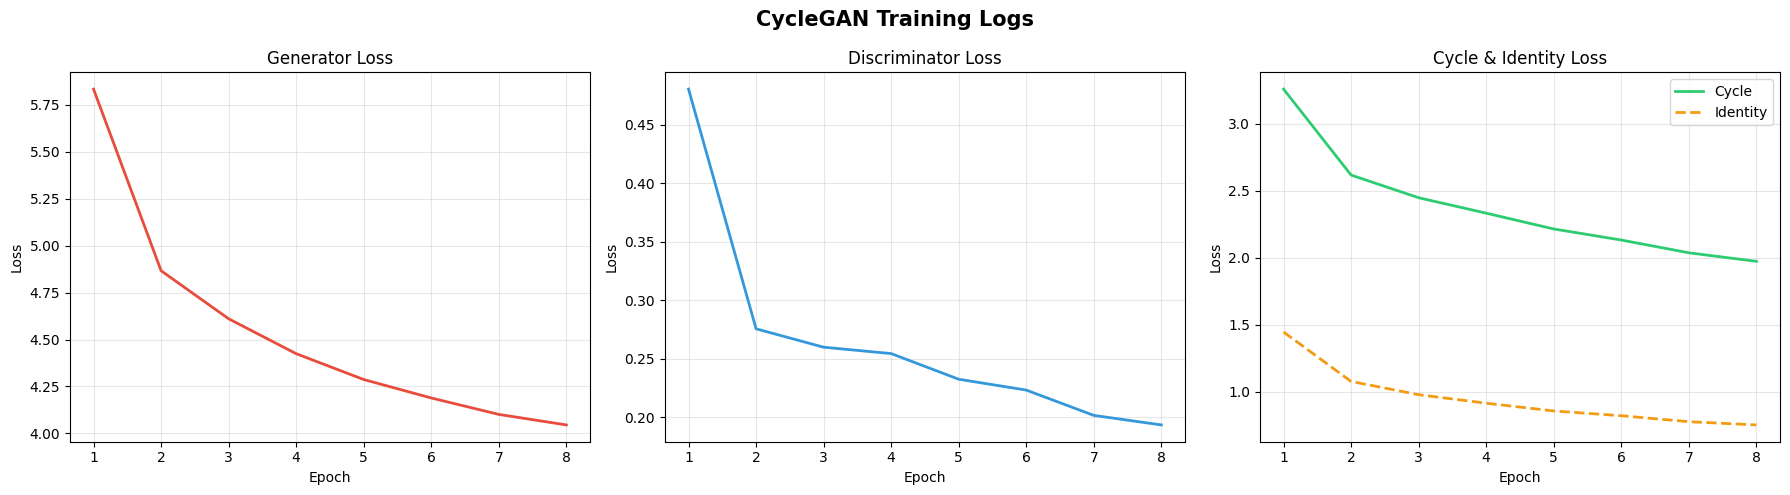

Loss curves saved.


In [14]:
epochs_range = range(1, len(history['loss_G']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CycleGAN Training Logs', fontsize=15, fontweight='bold')

# Generator Loss
axes[0].plot(epochs_range, history['loss_G'], color='#e74c3c', linewidth=2)
axes[0].set_title('Generator Loss', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Discriminator Loss
axes[1].plot(epochs_range, history['loss_D'], color='#3498db', linewidth=2)
axes[1].set_title('Discriminator Loss', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

# Cycle Consistency Loss
axes[2].plot(epochs_range, history['loss_cycle'], color='#2ecc71', linewidth=2, label='Cycle')
axes[2].plot(epochs_range, history['loss_id'], color='#f39c12', linewidth=2, linestyle='--', label='Identity')
axes[2].set_title('Cycle & Identity Loss', fontsize=12)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curves saved.')

## 10. Qualitative Evaluation — Visualization

IndexError: index 4 is out of bounds for dimension 0 with size 4

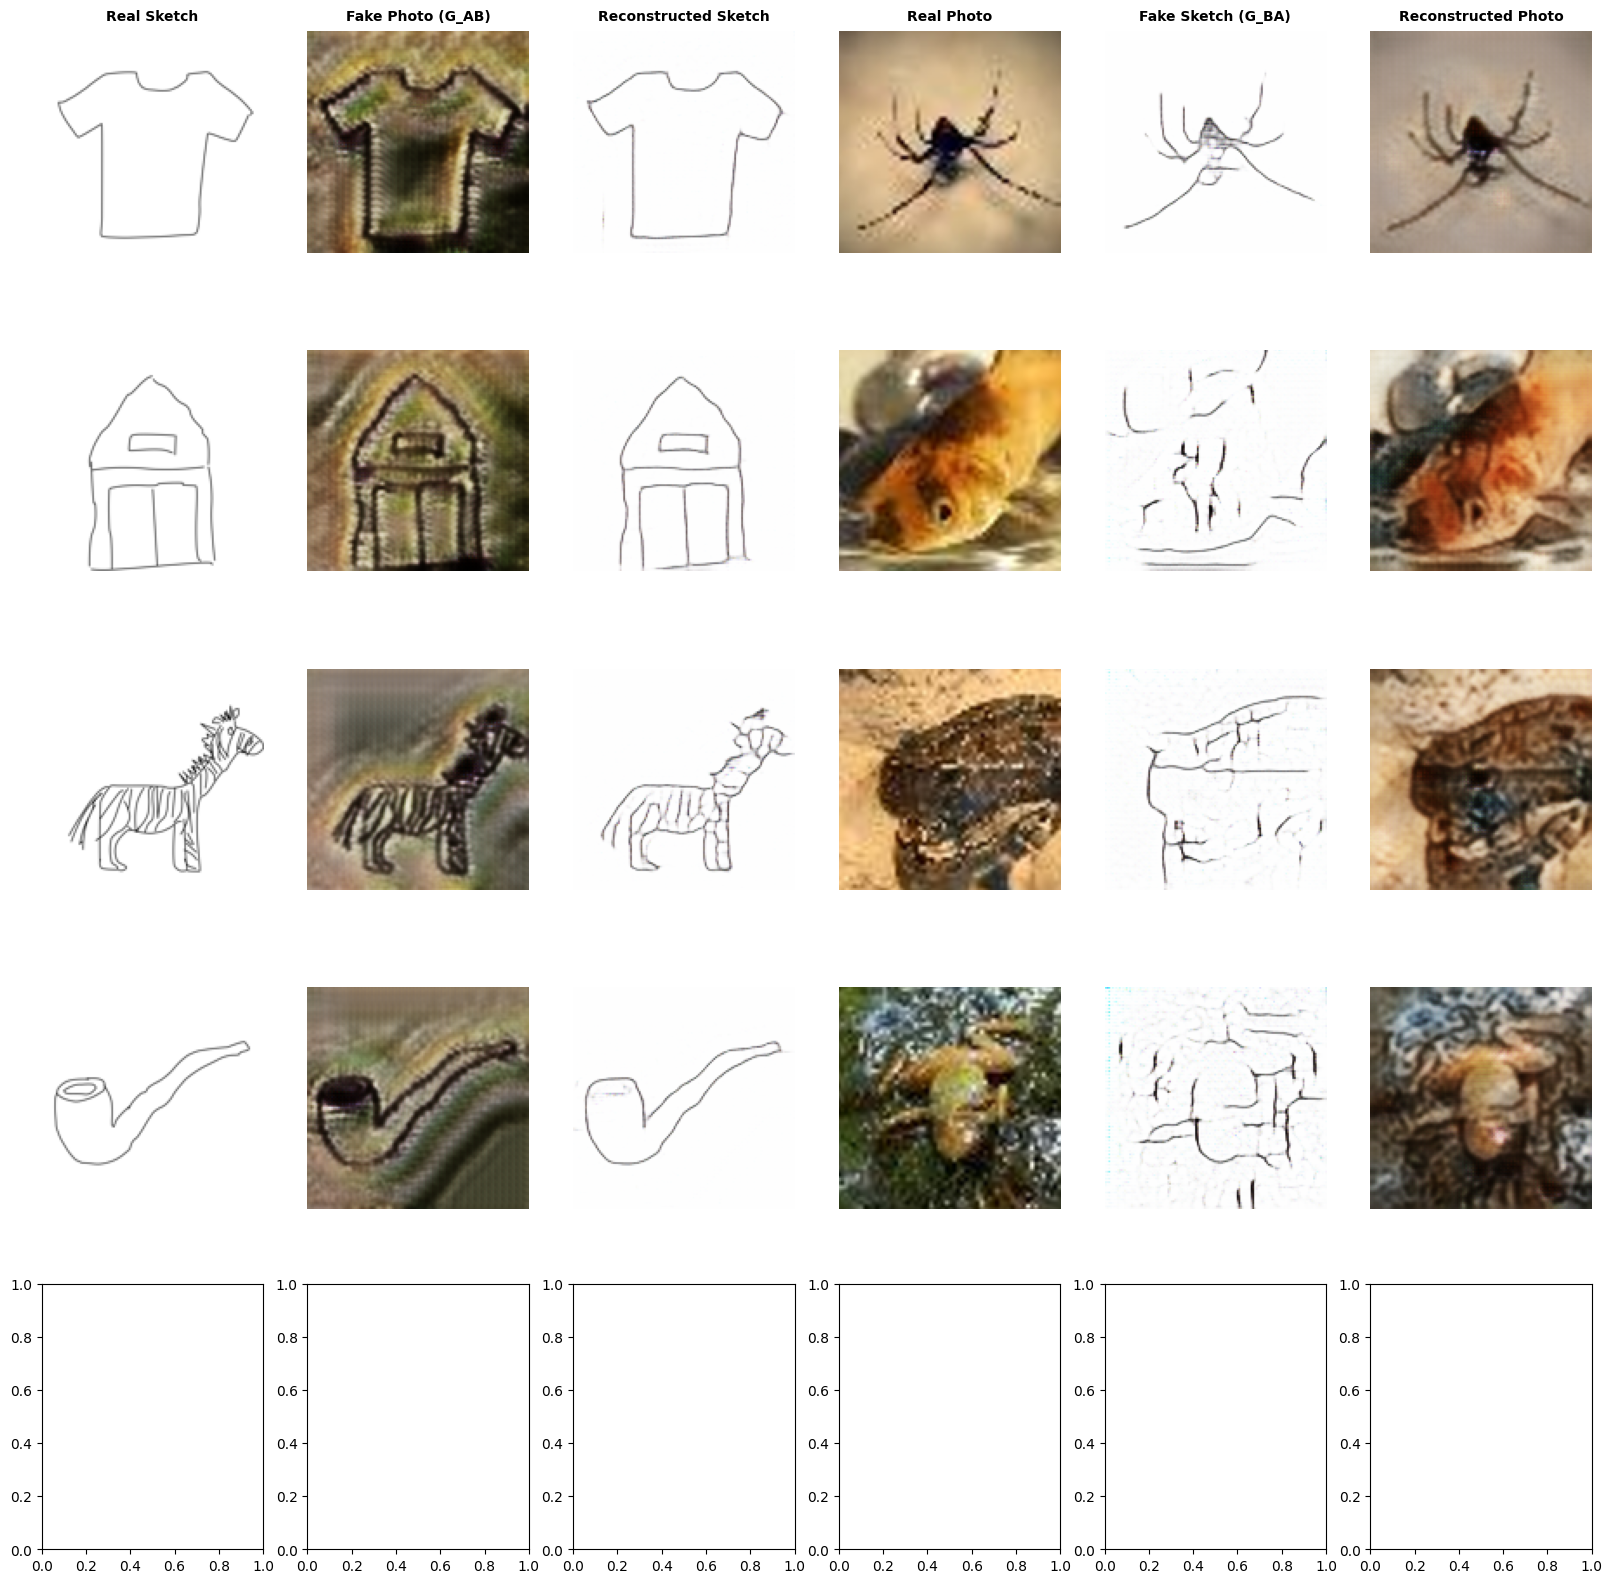

In [15]:
def visualize_translations(n_examples=5, save_path=None):
    G_AB.eval(); G_BA.eval()

    real_A_batch, real_B_batch = next(iter(val_loader))
    real_A_batch = real_A_batch[:n_examples].to(device)
    real_B_batch = real_B_batch[:n_examples].to(device)

    with torch.no_grad():
        fake_B  = G_AB(real_A_batch)    # Sketch → Photo
        recov_A = G_BA(fake_B)          # Reconstructed Sketch
        fake_A  = G_BA(real_B_batch)    # Photo → Sketch
        recov_B = G_AB(fake_A)          # Reconstructed Photo

    def to_np(t):
        return (t * 0.5 + 0.5).clamp(0, 1).cpu().permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(n_examples, 6, figsize=(20, 4 * n_examples))
    cols = ['Real Sketch', 'Fake Photo (G_AB)', 'Reconstructed Sketch',
            'Real Photo', 'Fake Sketch (G_BA)', 'Reconstructed Photo']

    for ax, title in zip(axes[0], cols):
        ax.set_title(title, fontsize=10, fontweight='bold', pad=8)

    for i in range(n_examples):
        imgs = [real_A_batch[i], fake_B[i], recov_A[i],
                real_B_batch[i], fake_A[i], recov_B[i]]
        for j, img in enumerate(imgs):
            axes[i, j].imshow(to_np(img))
            axes[i, j].axis('off')

    plt.suptitle('CycleGAN: Sketch ↔ Photo Translation', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved to {save_path}')
    plt.show()


visualize_translations(n_examples=5,
                       save_path=f'{cfg.OUTPUT_DIR}/qualitative_results.png')

## 11. Quantitative Evaluation — SSIM & PSNR

Computing SSIM and PSNR on validation set...

  Quantitative Evaluation Results
  SSIM_A→B→A               : 0.9310
  PSNR_A→B→A               : 24.8190
  SSIM_B→A→B               : 0.7565
  PSNR_B→A→B               : 20.5287


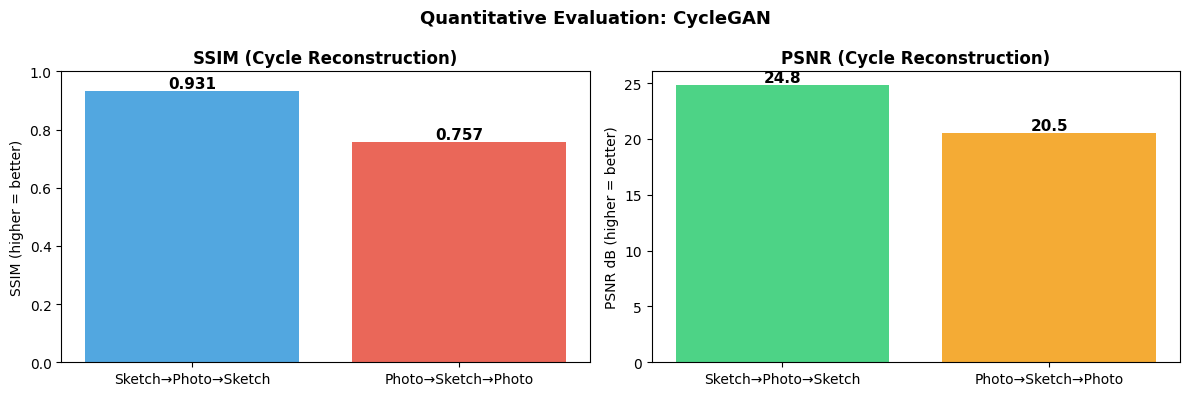

In [16]:
def evaluate_metrics(loader, n_batches=20):
    G_AB.eval(); G_BA.eval()

    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)

    ssim_ABA, psnr_ABA = [], []
    ssim_BAB, psnr_BAB = [], []

    with torch.no_grad():
        for i, (real_A, real_B) in enumerate(loader):
            if i >= n_batches: break
            real_A = real_A.to(device)
            real_B = real_B.to(device)

            # Denorm to [0,1] for metric computation
            real_A_d = (real_A * 0.5 + 0.5).clamp(0, 1)
            real_B_d = (real_B * 0.5 + 0.5).clamp(0, 1)

            fake_B   = G_AB(real_A)
            recov_A  = G_BA(fake_B)
            fake_A   = G_BA(real_B)
            recov_B  = G_AB(fake_A)

            recov_A_d = (recov_A * 0.5 + 0.5).clamp(0, 1)
            recov_B_d = (recov_B * 0.5 + 0.5).clamp(0, 1)

            # Cycle reconstruction quality: real vs reconstructed
            ssim_ABA.append(ssim_metric(recov_A_d, real_A_d).item())
            psnr_ABA.append(psnr_metric(recov_A_d, real_A_d).item())
            ssim_BAB.append(ssim_metric(recov_B_d, real_B_d).item())
            psnr_BAB.append(psnr_metric(recov_B_d, real_B_d).item())

    results = {
        'SSIM_A→B→A': np.mean(ssim_ABA),
        'PSNR_A→B→A': np.mean(psnr_ABA),
        'SSIM_B→A→B': np.mean(ssim_BAB),
        'PSNR_B→A→B': np.mean(psnr_BAB),
    }
    return results


print('Computing SSIM and PSNR on validation set...')
metrics = evaluate_metrics(val_loader)

print('\n' + '='*45)
print('  Quantitative Evaluation Results')
print('='*45)
for k, v in metrics.items():
    print(f'  {k:<25}: {v:.4f}')
print('='*45)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ssim_vals = [metrics['SSIM_A→B→A'], metrics['SSIM_B→A→B']]
psnr_vals = [metrics['PSNR_A→B→A'], metrics['PSNR_B→A→B']]
labels = ['Sketch→Photo→Sketch', 'Photo→Sketch→Photo']

axes[0].bar(labels, ssim_vals, color=['#3498db', '#e74c3c'], alpha=0.85)
axes[0].set_title('SSIM (Cycle Reconstruction)', fontweight='bold')
axes[0].set_ylabel('SSIM (higher = better)')
axes[0].set_ylim(0, 1)
for i, v in enumerate(ssim_vals):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

axes[1].bar(labels, psnr_vals, color=['#2ecc71', '#f39c12'], alpha=0.85)
axes[1].set_title('PSNR (Cycle Reconstruction)', fontweight='bold')
axes[1].set_ylabel('PSNR dB (higher = better)')
for i, v in enumerate(psnr_vals):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Quantitative Evaluation: CycleGAN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/quantitative_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Final Model

In [17]:
final_path = os.path.join(cfg.CHECKPOINT_DIR, 'cyclegan_final.pth')
torch.save({
    'G_AB_state_dict': G_AB.state_dict(),
    'G_BA_state_dict': G_BA.state_dict(),
    'config': {
        'in_channels':  cfg.IN_CHANNELS,
        'n_features':   cfg.N_FEATURES,
        'n_res_blocks': cfg.N_RESBLOCKS,
        'image_size':   cfg.IMAGE_SIZE,
    },
    'metrics': metrics,
    'history': history,
}, final_path)
print(f'Final model saved to: {final_path}')

import shutil
for f in glob(f'{cfg.OUTPUT_DIR}/*.png'):
    print(f'Output: {f}')

Final model saved to: /kaggle/working/checkpoints/cyclegan_final.pth
Output: /kaggle/working/outputs/quantitative_metrics.png
Output: /kaggle/working/outputs/training_loss_curves.png
Output: /kaggle/working/outputs/sample_data.png


## 13. Gradio App Deployment

In [19]:
import gradio as gr
import torchvision.transforms.functional as TF


def load_inference_models(checkpoint_path):
    g_ab = GeneratorResNet(cfg.IN_CHANNELS, cfg.N_FEATURES, cfg.N_RESBLOCKS)
    g_ba = GeneratorResNet(cfg.IN_CHANNELS, cfg.N_FEATURES, cfg.N_RESBLOCKS)

    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)  # ← fix here

    def strip_dp(state):
        return {k.replace('module.', ''): v for k, v in state.items()}

    g_ab.load_state_dict(strip_dp(ckpt['G_AB_state_dict']))
    g_ba.load_state_dict(strip_dp(ckpt['G_BA_state_dict']))

    g_ab.eval(); g_ba.eval()
    return g_ab.to(device), g_ba.to(device)


def preprocess_image(pil_img):
    transform = transforms.Compose([
        transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE), Image.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    return transform(pil_img.convert('RGB')).unsqueeze(0).to(device)


def postprocess_tensor(t):
    img = (t.squeeze(0).cpu() * 0.5 + 0.5).clamp(0, 1)
    return TF.to_pil_image(img)


# Load the best saved model
inf_G_AB, inf_G_BA = load_inference_models(
    os.path.join(cfg.CHECKPOINT_DIR, 'cyclegan_final.pth')
)


def translate_image(input_pil, direction):
    """
    Gradio callback.
    direction: 'Sketch → Photo' or 'Photo → Sketch'
    """
    tensor = preprocess_image(input_pil)
    with torch.no_grad(), autocast():
        if direction == 'Sketch → Photo':
            out_tensor = inf_G_AB(tensor)
        else:
            out_tensor = inf_G_BA(tensor)
    return postprocess_tensor(out_tensor)


# ─── Build Gradio UI ──────────────────────────────────────────────────────────
with gr.Blocks(
    title='CycleGAN Sketch ↔ Photo',
    theme=gr.themes.Soft(primary_hue='blue'),
    css='''
        .title { text-align: center; font-size: 2rem; font-weight: 700;
                 background: linear-gradient(135deg, #2980b9, #8e44ad);
                 -webkit-background-clip: text; -webkit-text-fill-color: transparent; }
        .subtitle { text-align: center; color: #555; margin-bottom: 1rem; }
        footer { visibility: hidden; }
    '''
) as demo:

    gr.Markdown('<div class="title">🎨 CycleGAN — Sketch ↔ Photo Translator</div>')
    gr.Markdown('<div class="subtitle">Upload a sketch to generate a photo, or a photo to generate a sketch.</div>')

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type='pil', label='Input Image', height=300)
            direction   = gr.Radio(
                choices=['Sketch → Photo', 'Photo → Sketch'],
                value='Sketch → Photo',
                label='Translation Direction'
            )
            btn = gr.Button('Translate ✨', variant='primary', size='lg')

        with gr.Column():
            output_image = gr.Image(type='pil', label='Translated Output', height=300)
            gr.Markdown('### About')
            gr.Markdown(
                'Model: **CycleGAN** (ResNet-6 Generator + PatchGAN Discriminator)  \n'
                'Trained on: TU-Berlin Sketches + Natural Photos  \n'
                'Image size: 128 × 128'
            )

    btn.click(fn=translate_image,
              inputs=[input_image, direction],
              outputs=output_image)

    gr.Examples(
        examples=[[f, 'Sketch → Photo'] for f in glob(cfg.SKETCH_DIR+'/*.png')[:3]] +
                 [[f, 'Photo → Sketch'] for f in glob(cfg.PHOTO_DIR+'/*.jpg')[:3]],
        inputs=[input_image, direction],
        outputs=output_image,
        fn=translate_image,
        cache_examples=True,
    )

print('Launching Gradio app...')
demo.launch(share=True)   # share=True gives a public Gradio link on Kaggle

Launching Gradio app...
* Running on local URL:  http://127.0.0.1:7860
Caching examples at: '/kaggle/working/.gradio/cached_examples/13'
* Running on public URL: https://39dcad33cef45bbb49.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---

## Summary

| Component | Details |
|---|---|
| Generator | ResNet-6, 128×128, InstanceNorm |
| Discriminator | PatchGAN (70×70 receptive field) |
| Losses | LSGAN adversarial + Cycle (λ=10) + Identity (λ=5) |
| Optimizer | Adam (lr=0.0002, β=(0.5,0.999)) |
| Precision | Mixed (AMP + GradScaler) |
| Hardware | Kaggle T4 × 2 (DataParallel) |
| Metrics | SSIM, PSNR (cycle reconstruction) |
| Deployment | Gradio (share=True) |